# Notebook 01: Data Ingestion & Exploratory Data Analysis

**Project**: ML Analysis of Property Tax Shift Effects in Cook County, IL

**Goal**: Download CCAO open data, understand its structure, and identify
the key columns needed for our AVM and tax shift simulation.

**Data Sources**:
- `training_data.parquet` — ~400K residential sales (9 years) with ~100 features
- `assessment_data.parquet` — ~1.1M residential properties (all, sold + unsold)
- `land_nbhd_rate_data.parquet` — CCAO neighborhood-level land rates ($/sqft)

## 1. Setup & Data Download

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
from pathlib import Path
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.2f}".format)
# Create data directories
Path("../data/raw").mkdir(parents=True, exist_ok=True)
Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
Path("../outputs/models").mkdir(parents=True, exist_ok=True)

In [2]:
# === Download parquet files from CCAO public S3 ===
# Using 2025 data (most recent complete year with public links)
# Change to 2026 if you want the latest (South suburbs triad)
BASE_URL = "https://ccao-data-public-us-east-1.s3.amazonaws.com/models/inputs/res/2025"
FILES = {
    "training_data.parquet": f"{BASE_URL}/training_data.parquet",
    "assessment_data.parquet": f"{BASE_URL}/assessment_data.parquet",
    "land_nbhd_rate_data.parquet": f"{BASE_URL}/land_nbhd_rate_data.parquet",
}
for filename, url in FILES.items():
    filepath = f"../data/raw/{filename}"
    if not os.path.exists(filepath):
        print(f"Downloading {filename}...")
        resp = requests.get(url, stream=True)
        resp.raise_for_status()
        with open(filepath, "wb") as f:
            for chunk in resp.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"  Saved to {filepath}")
    else:
        print(f"  {filename} already exists, skipping download.")

  Saved to ../data/raw/training_data.parquet
  Saved to ../data/raw/assessment_data.parquet
  Saved to ../data/raw/land_nbhd_rate_data.parquet


In [3]:
# === Load the data ===
print("Loading training data...")
training = pd.read_parquet("../data/raw/training_data.parquet")
print(f"  Training shape: {training.shape}")
print("Loading assessment data...")
assessment = pd.read_parquet("../data/raw/assessment_data.parquet")
print(f"  Assessment shape: {assessment.shape}")
print("Loading land rate data...")
land_rates = pd.read_parquet("../data/raw/land_nbhd_rate_data.parquet")
print(f"  Land rates shape: {land_rates.shape}")

Loading training data...
  Training shape: (413289, 201)
Loading assessment data...
  Assessment shape: (1100173, 191)
Loading land rate data...
  Land rates shape: (5040, 3)


## 2. Initial Exploration of Training Data

In [4]:
# Column overview — group by prefix to understand the feature categories
print("=== Training Data: Column Prefixes ===")
prefixes = {}
for col in sorted(training.columns):
    prefix = col.split("_")[0]
    prefixes.setdefault(prefix, []).append(col)
for prefix, cols in sorted(prefixes.items()):
    print(f"\n{prefix.upper()} ({len(cols)} columns):")
    for c in cols:
        print(f"  {c}: {training[c].dtype}", end="")
        if training[c].dtype in ["float64", "int64", "float32", "int32"]:
            print(f"  [non-null: {training[c].notna().sum()}/{len(training)}]", end="")
        print()

=== Training Data: Column Prefixes ===

ACS5 (22 columns):
  acs5_count_sex_total: float64  [non-null: 413275/413289]
  acs5_median_age_total: float64  [non-null: 413185/413289]
  acs5_median_household_owner_occupied_value: float64  [non-null: 411920/413289]
  acs5_median_household_renter_occupied_gross_rent: float64  [non-null: 399761/413289]
  acs5_median_household_total_occupied_year_built: float64  [non-null: 366900/413289]
  acs5_median_income_household_past_year: float64  [non-null: 412612/413289]
  acs5_median_income_per_capita_past_year: float64  [non-null: 413221/413289]
  acs5_percent_age_children: float64  [non-null: 413275/413289]
  acs5_percent_age_senior: float64  [non-null: 413275/413289]
  acs5_percent_education_bachelor: float64  [non-null: 413131/413289]
  acs5_percent_education_graduate: float64  [non-null: 413131/413289]
  acs5_percent_education_high_school: float64  [non-null: 413131/413289]
  acs5_percent_employment_unemployed: float64  [non-null: 413221/413289]
 

In [5]:
# Target variable
target_col = "meta_sale_price"
print(f"=== Sale Price Distribution ===")
print(f"Target column: {target_col}")
print(training[target_col].describe())

=== Sale Price Distribution ===
Target column: meta_sale_price
count     413289.00
mean      362550.70
std       361619.49
min        10001.00
25%       172500.00
50%       275000.00
75%       425000.00
max     16000000.00
Name: meta_sale_price, dtype: float64


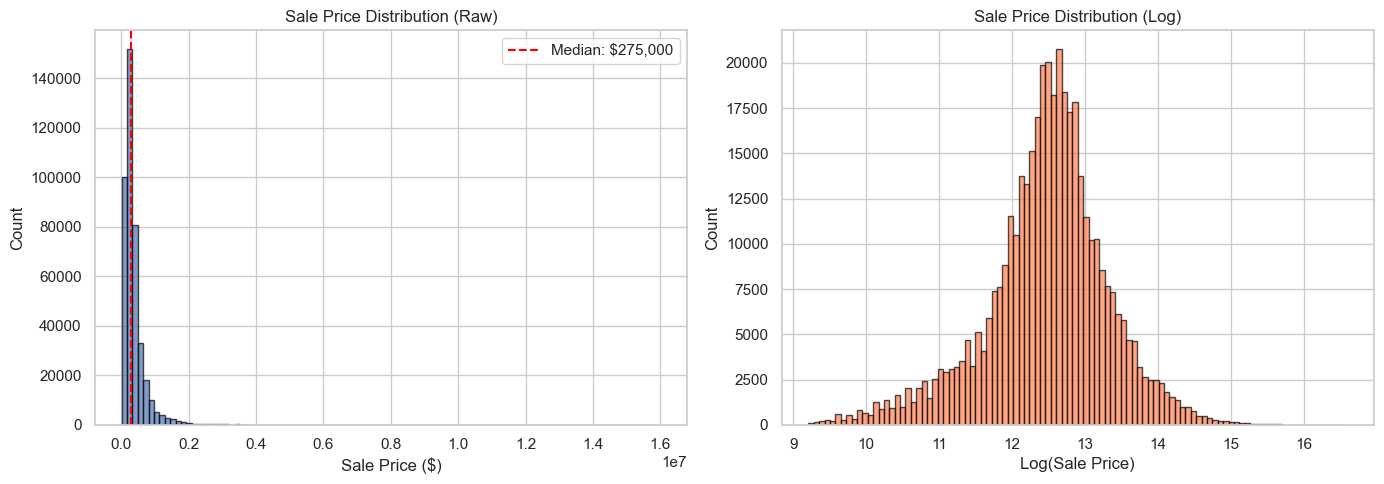

In [6]:
# If we found the target, plot its distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
# Raw distribution
axes[0].hist(training[target_col].dropna(), bins=100, edgecolor="black", alpha=0.7)
axes[0].set_title("Sale Price Distribution (Raw)")
axes[0].set_xlabel("Sale Price ($)")
axes[0].set_ylabel("Count")
axes[0].axvline(training[target_col].median(), color="red", linestyle="--", 
                     label=f"Median: ${training[target_col].median():,.0f}")
axes[0].legend()
    
# Log distribution
log_prices = np.log1p(training[target_col].dropna())
axes[1].hist(log_prices, bins=100, edgecolor="black", alpha=0.7, color="coral")
axes[1].set_title("Sale Price Distribution (Log)")
axes[1].set_xlabel("Log(Sale Price)")
axes[1].set_ylabel("Count")
    
plt.tight_layout()
plt.savefig("../outputs/figures/01_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Property Characteristics Deep Dive

In [8]:
# Focus on characteristic columns — these are the building blocks for the AVM
char_cols = [c for c in training.columns if c.startswith("char_")]
print(f"=== Property Characteristics ({len(char_cols)} columns) ===\n")
for col in sorted(char_cols):
    dtype = training[col].dtype
    n_unique = training[col].nunique()
    n_null = training[col].isna().sum()
    pct_null = 100 * n_null / len(training)

    if pd.api.types.is_numeric_dtype(training[col]):
        print(f"{col} [{dtype}] — {pct_null:.1f}% null")
        print(f"  Range: [{training[col].min()}, {training[col].max()}], "
              f"Mean: {training[col].mean():.2f}, Median: {training[col].median():.2f}")
    else:
        top_vals = training[col].value_counts().head(5).to_dict()
        print(f"{col} [{dtype}] — {n_unique} unique, {pct_null:.1f}% null")
        print(f"  Top values: {top_vals}")
    print()

=== Property Characteristics (32 columns) ===

char_air [category] — 2 unique, 0.0% null
  Top values: {'2': 210871, '1': 202344}

char_apts [category] — 7 unique, 0.0% null
  Top values: {'NONE': 350716, 'TWO': 35478, 'THREE': 13507, 'FOUR': 5208, 'SIX': 3972}

char_attic_fnsh [category] — 3 unique, 0.1% null
  Top values: {'3': 358743, '1': 51394, '2': 2747}

char_attic_type [category] — 3 unique, 0.0% null
  Top values: {'3': 281619, '1': 76380, '2': 55243}

char_beds [float64] — 0.0% null
  Range: [1.0, 34.0], Mean: 3.57, Median: 3.00

char_bldg_sf [float64] — 0.0% null
  Range: [309.0, 19992.0], Mean: 1837.08, Median: 1500.00

char_bldg_sf_95_percentile [float64] — 0.0% null
  Range: [2540.0, 7335.0], Mean: 3670.18, Median: 3470.00

char_bsmt [category] — 4 unique, 0.0% null
  Top values: {'1': 246989, '3': 85827, '2': 57335, '4': 23064}

char_bsmt_fin [category] — 3 unique, 0.1% null
  Top values: {'3': 278479, '1': 126086, '2': 8508}

char_class [str] — 17 unique, 0.0% null
  To

=== Land SF vs Building SF ===
Land SF:  {'count': 413214.0, 'mean': 7348.918662000803, 'std': 13977.2654071795, 'min': 358.0, '25%': 3720.0, '50%': 5190.0, '75%': 8062.75, 'max': 2363130.0}
Bldg SF:  {'count': 413214.0, 'mean': 1837.0377576751998, 'std': 1065.5123366641378, 'min': 309.0, '25%': 1139.0, '50%': 1500.0, '75%': 2218.0, 'max': 19992.0}
Bldg/Land Ratio: {'count': 413214.0, 'mean': 0.3897372208890382, 'std': 0.35024483933379874, 'min': 0.0007839674627449661, '25%': 0.1828358208955224, '50%': 0.27190794456645406, '75%': 0.46260869565217394, 'max': 6.48135593220339}


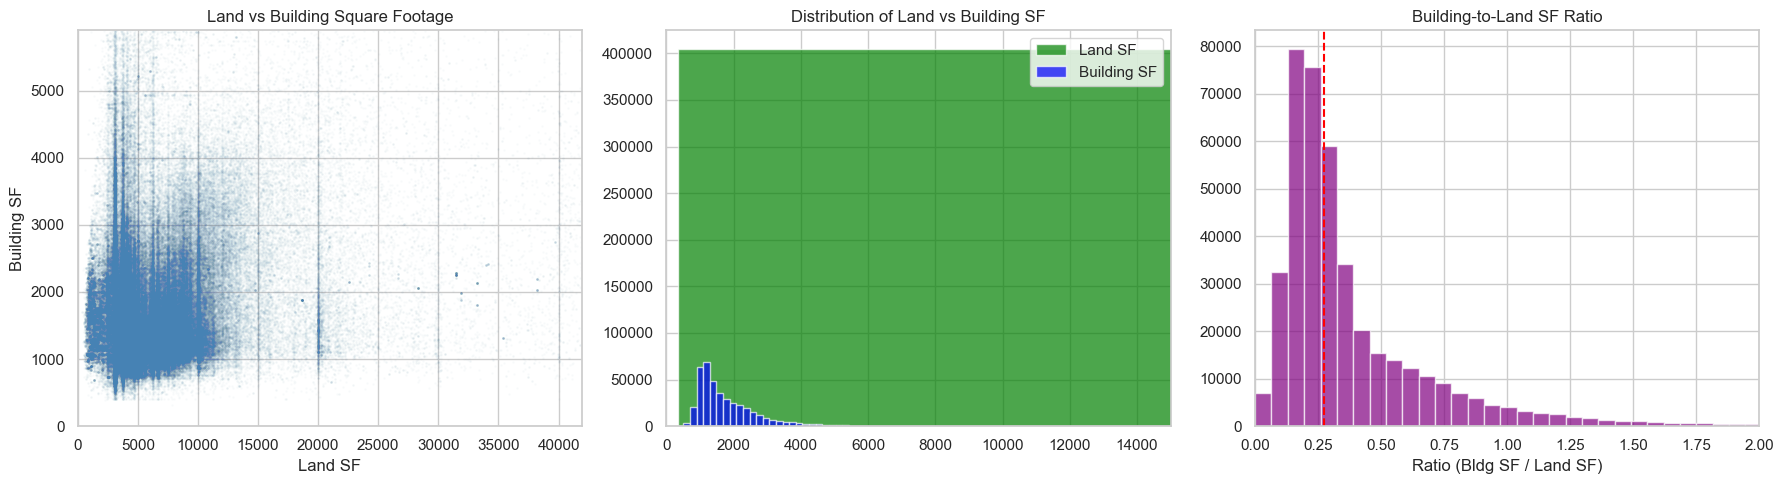

In [9]:
# === CRITICAL: Land SF vs Building SF ===
# These two columns are the foundation of land-improvement decomposition
if "char_land_sf" in training.columns and "char_bldg_sf" in training.columns:
    print("=== Land SF vs Building SF ===")
    
    subset = training[["char_land_sf", "char_bldg_sf"]].dropna()
    subset = subset[(subset["char_land_sf"] > 0) & (subset["char_bldg_sf"] > 0)]
    
    # Compute improvement-to-land ratio
    subset["bldg_to_land_ratio"] = subset["char_bldg_sf"] / subset["char_land_sf"]
    
    print(f"Land SF:  {subset['char_land_sf'].describe().to_dict()}")
    print(f"Bldg SF:  {subset['char_bldg_sf'].describe().to_dict()}")
    print(f"Bldg/Land Ratio: {subset['bldg_to_land_ratio'].describe().to_dict()}")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].scatter(subset["char_land_sf"], subset["char_bldg_sf"], 
                    alpha=0.02, s=1, color="steelblue")
    axes[0].set_xlabel("Land SF")
    axes[0].set_ylabel("Building SF")
    axes[0].set_title("Land vs Building Square Footage")
    axes[0].set_xlim(0, subset["char_land_sf"].quantile(0.99))
    axes[0].set_ylim(0, subset["char_bldg_sf"].quantile(0.99))
    
    axes[1].hist(subset["char_land_sf"], bins=100, alpha=0.7, label="Land SF", color="green")
    axes[1].hist(subset["char_bldg_sf"], bins=100, alpha=0.7, label="Building SF", color="blue")
    axes[1].set_xlim(0, 15000)
    axes[1].set_title("Distribution of Land vs Building SF")
    axes[1].legend()
    
    axes[2].hist(subset["bldg_to_land_ratio"], bins=100, alpha=0.7, color="purple")
    axes[2].set_title("Building-to-Land SF Ratio")
    axes[2].set_xlabel("Ratio (Bldg SF / Land SF)")
    axes[2].axvline(subset["bldg_to_land_ratio"].median(), color="red", linestyle="--")
    axes[2].set_xlim(0, 2)
    
    plt.tight_layout()
    plt.savefig("../outputs/figures/01_land_vs_building_sf.png", dpi=150, bbox_inches="tight")
    plt.show()

## 4. Property Class Distribution

=== Property Class Distribution (column: char_class) ===

Class    Description                    Count      Pct
-------------------------------------------------------
202      1-Story SF                    43,616    10.6%
203      1-Story SF (lg lot)          126,056    30.5%
204      A-Frame SF                    17,819     4.3%
205      1.5-Story SF                  29,060     7.0%
206      2-Story SF                    12,756     3.1%
207      2+ Story SF                   10,295     2.5%
208      2-Story SF (lg lot)            4,535     1.1%
209      Split Level SF                 2,060     0.5%
210      Townhouse/Row                  5,338     1.3%
211      2-Unit Apt                    59,194    14.3%
212      3-6 Unit Apt                   3,642     0.9%
218      Other                              6     0.0%
219      Other                              1     0.0%
234      Split Use                     34,232     8.3%
278      SF w/ coach house             34,980     8.5%
295   

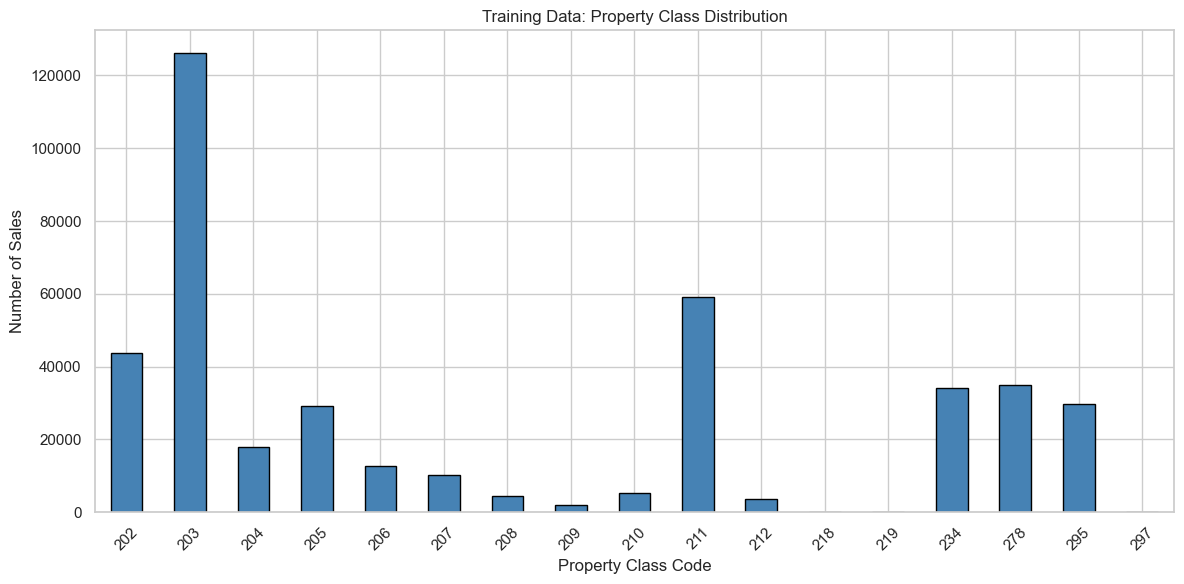

In [10]:
# Property class is critical — it determines the assessment level (10% vs 25%)
# and is central to the tax shift simulation
class_col = None
for candidate in ["char_class", "meta_class", "class"]:
    if candidate in training.columns:
        class_col = candidate
        break

if class_col:
    print(f"=== Property Class Distribution (column: {class_col}) ===\n")
    class_counts = training[class_col].value_counts().sort_index()
    
    # Cook County residential class descriptions
    class_labels = {
        "200": "Vacant Land",
        "202": "1-Story SF",
        "203": "1-Story SF (lg lot)",
        "204": "A-Frame SF",
        "205": "1.5-Story SF",
        "206": "2-Story SF",
        "207": "2+ Story SF",
        "208": "2-Story SF (lg lot)",
        "209": "Split Level SF",
        "210": "Townhouse/Row",
        "211": "2-Unit Apt",
        "212": "3-6 Unit Apt",
        "234": "Split Use",
        "278": "SF w/ coach house",
        "295": "Townhouse (condo-like)",
    }
    
    print(f"{'Class':<8} {'Description':<25} {'Count':>10} {'Pct':>8}")
    print("-" * 55)
    for cls, count in class_counts.items():
        desc = class_labels.get(str(cls), "Other")
        pct = 100 * count / len(training)
        print(f"{str(cls):<8} {desc:<25} {count:>10,} {pct:>7.1f}%")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(12, 6))
    class_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title("Training Data: Property Class Distribution")
    ax.set_xlabel("Property Class Code")
    ax.set_ylabel("Number of Sales")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig("../outputs/figures/01_class_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

## 5. Location & Geographic Coverage

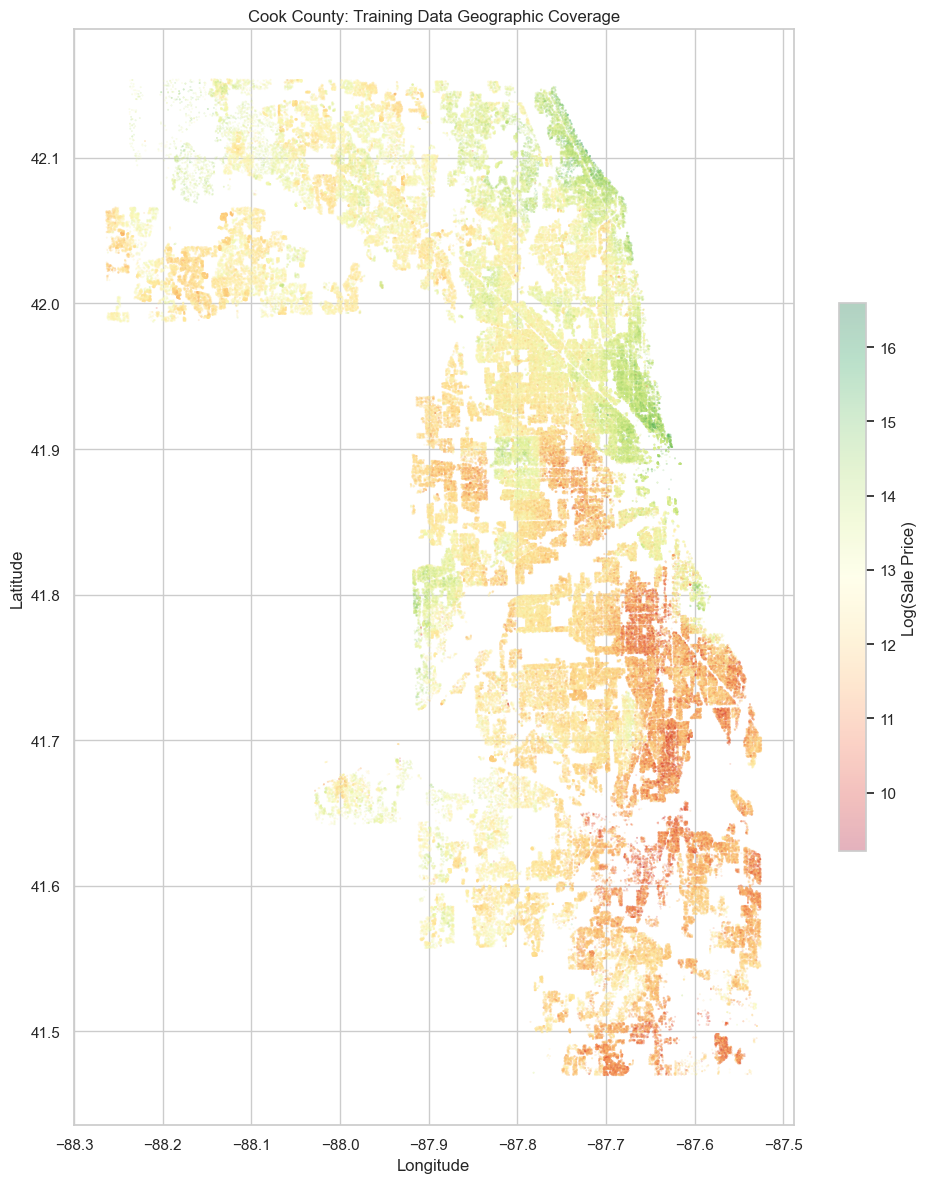

Latitude range:  41.4699 to 42.1540
Longitude range: -88.2635 to -87.5249


In [11]:
# Check geographic spread
if "loc_latitude" in training.columns and "loc_longitude" in training.columns:
    geo = training[["loc_latitude", "loc_longitude"]].dropna()
    
    fig, ax = plt.subplots(figsize=(10, 12))
    
    if target_col:
        # Color by sale price (log scale)
        prices = training.loc[geo.index, target_col]
        valid = prices.notna()
        scatter = ax.scatter(
            geo.loc[valid.index[valid], "loc_longitude"],
            geo.loc[valid.index[valid], "loc_latitude"],
            c=np.log1p(prices[valid]),
            cmap="RdYlGn",
            s=0.1,
            alpha=0.3,
        )
        plt.colorbar(scatter, ax=ax, label="Log(Sale Price)", shrink=0.5)
    else:
        ax.scatter(geo["loc_longitude"], geo["loc_latitude"], s=0.1, alpha=0.3)
    
    ax.set_title("Cook County: Training Data Geographic Coverage")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.savefig("../outputs/figures/01_geographic_coverage.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"Latitude range:  {geo['loc_latitude'].min():.4f} to {geo['loc_latitude'].max():.4f}")
    print(f"Longitude range: {geo['loc_longitude'].min():.4f} to {geo['loc_longitude'].max():.4f}")

## 6. Township & Neighborhood Analysis

=== Township-Level Sale Price Statistics ===

                    n_sales  mean_price  median_price  std_price
meta_township_code                                              
74                     2795  1590717.81    1320000.00 1081760.26
23                     8115  1170058.82     925000.00  935124.28
73                    10850  1024290.07     882000.00  543061.45
33                     1238   738538.09     655000.00  357602.85
25                     9351   716036.83     615000.00  425147.68
10                     2331   710026.85     589000.00  455703.93
17                     4801   637142.65     532500.00  425236.48
27                     5284   506902.47     465250.00  224598.34
75                     2479   465333.59     425000.00  226225.47
19                     2893   444038.75     424900.00  192288.96
76                     5618   450585.95     400000.00  289745.77
71                    42042   411097.65     370000.00  205948.49
24                     8734   407552.74     

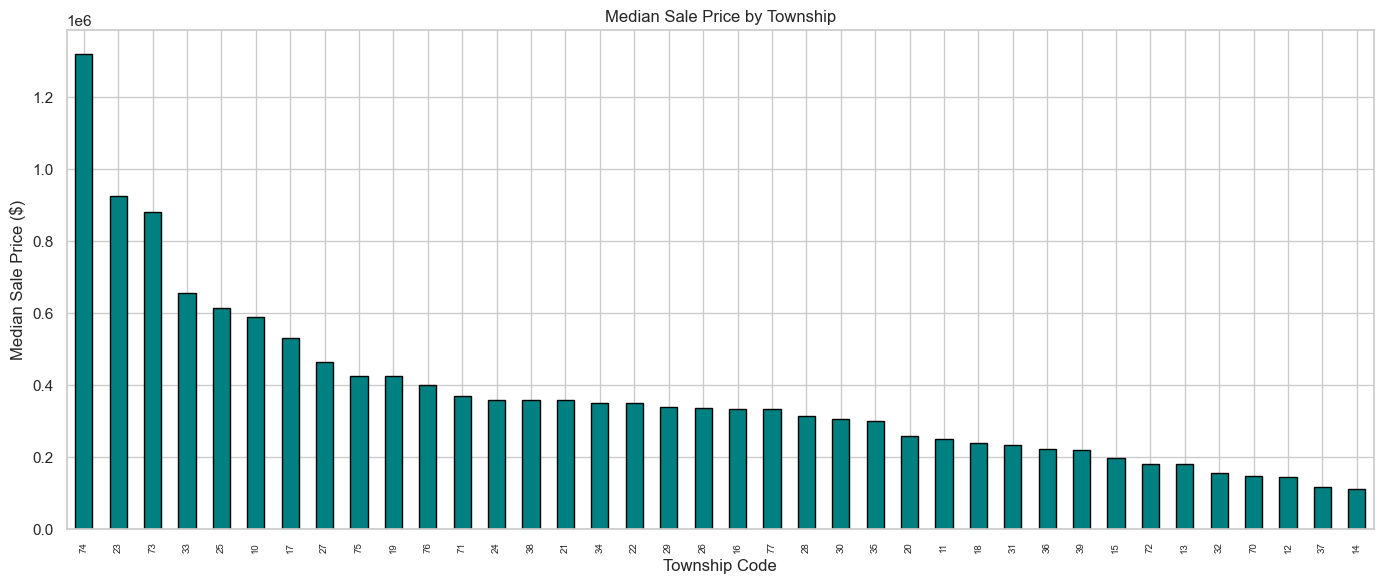

In [12]:
# Township-level statistics — important because Cook County assesses by triad
township_col = None
for candidate in ["meta_township_code", "township_code"]:
    if candidate in training.columns:
        township_col = candidate
        break

if township_col and target_col:
    township_stats = (
        training.groupby(township_col)[target_col]
        .agg(["count", "mean", "median", "std"])
        .sort_values("median", ascending=False)
    )
    township_stats.columns = ["n_sales", "mean_price", "median_price", "std_price"]
    
    print("=== Township-Level Sale Price Statistics ===\n")
    print(township_stats.head(20).to_string())
    
    fig, ax = plt.subplots(figsize=(14, 6))
    township_stats["median_price"].plot(kind="bar", ax=ax, color="teal", edgecolor="black")
    ax.set_title("Median Sale Price by Township")
    ax.set_ylabel("Median Sale Price ($)")
    ax.set_xlabel("Township Code")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    plt.tight_layout()
    plt.savefig("../outputs/figures/01_township_prices.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. ACS / Census Feature Overview

In [13]:
acs_cols = [c for c in training.columns if c.startswith("acs5_")]
print(f"=== ACS/Census Features ({len(acs_cols)} columns) ===\n")
if acs_cols:
    acs_stats = training[acs_cols].describe().T
    acs_stats = acs_stats[["count", "mean", "std", "min", "50%", "max"]]
    acs_stats.columns = ["count", "mean", "std", "min", "median", "max"]
    print(acs_stats.to_string())

=== ACS/Census Features (22 columns) ===

                                                          count      mean       std     min    median        max
acs5_count_sex_total                                  413275.00   4670.77   1684.28  433.00   4646.00   20087.00
acs5_percent_age_children                             413275.00      0.25      0.06    0.00      0.25       0.58
acs5_percent_age_senior                               413275.00      0.16      0.06    0.00      0.16       0.56
acs5_median_age_total                                 413185.00     39.38      6.16   15.90     39.40      67.70
acs5_percent_mobility_no_move                         413221.00      0.89      0.06    0.33      0.91       1.00
acs5_percent_mobility_moved_in_county                 413221.00      0.08      0.05    0.00      0.07       0.63
acs5_percent_mobility_moved_from_other_state          413221.00      0.01      0.02    0.00      0.01       0.33
acs5_percent_household_family_married                 

## 8. Land Rate Data Exploration

In [14]:
print("=== Land Neighborhood Rate Data ===\n")
print(f"Shape: {land_rates.shape}")
print(f"Columns: {land_rates.columns.tolist()}")
print()
print(land_rates.head(10))
print()
print(land_rates.describe())

=== Land Neighborhood Rate Data ===

Shape: (5040, 3)
Columns: ['meta_nbhd', 'meta_class', 'land_rate_per_sqft']

  meta_nbhd meta_class  land_rate_per_sqft
0     10011        202                6.00
1     10011        203                6.00
2     10011        204                6.00
3     10011        205                6.00
4     10011        206                6.00
5     10011        207                6.00
6     10011        208                6.00
7     10011        209                6.00
8     10011        210                6.00
9     10011        211                6.00

       land_rate_per_sqft
count             5040.00
mean                14.10
std                  8.58
min                  0.50
25%                  9.00
50%                 12.00
75%                 16.62
max                120.00


## 9. Missing Data Analysis

In [15]:
# Missing data heatmap for characteristic and location columns
important_cols = [c for c in training.columns 
                  if c.startswith(("char_", "loc_", "prox_", "acs5_"))]
missing_pct = training[important_cols].isna().mean().sort_values(ascending=False)
missing_nonzero = missing_pct[missing_pct > 0]

if len(missing_nonzero) > 0:
    print(f"=== Columns with Missing Values ({len(missing_nonzero)} / {len(important_cols)}) ===\n")
    for col, pct in missing_nonzero.items():
        bar = "\u2588" * int(pct * 50)
        print(f"  {col:<50} {pct:>6.1%} {bar}")
else:
    print("No missing values in characteristic/location/proximity/ACS columns!")

=== Columns with Missing Values (120 / 125) ===

  loc_tax_special_service_area_num                    97.4% ████████████████████████████████████████████████
  loc_school_unified_district_geoid                   96.1% ████████████████████████████████████████████████
  loc_tax_tif_district_num                            92.4% ██████████████████████████████████████████████
  loc_chicago_community_area_name                     59.6% █████████████████████████████
  loc_ward_num                                        58.3% █████████████████████████████
  char_tp_dsgn                                        52.3% ██████████████████████████
  prox_nearest_road_highway_speed_limit               43.6% █████████████████████
  char_tp_plan                                        27.1% █████████████
  prox_avg_school_rating_in_half_mile                 25.1% ████████████
  prox_nearest_road_collector_speed_limit             17.4% ████████
  char_gar1_cnst                                      15.7% █

In [16]:
# Overall missingness summary
total_missing = training.isna().sum()
total_missing = total_missing[total_missing > 0].sort_values(ascending=False)
print(f"\n=== All Columns with Any Missing Values ({len(total_missing)}) ===\n")
for col, count in total_missing.head(30).items():
    pct = 100 * count / len(training)
    print(f"  {col:<55} {count:>8,} ({pct:.1f}%)")


=== All Columns with Any Missing Values (158) ===

  meta_tieback_key_pin                                     412,460 (99.8%)
  loc_tax_special_service_area_num                         402,387 (97.4%)
  loc_school_unified_district_geoid                        397,376 (96.1%)
  sv_outlier_reason3                                       395,524 (95.7%)
  loc_tax_tif_district_num                                 381,914 (92.4%)
  sv_outlier_reason2                                       331,797 (80.3%)
  loc_chicago_community_area_name                          246,149 (59.6%)
  other_distressed_community_index                         242,566 (58.7%)
  other_affordability_risk_index                           242,542 (58.7%)
  loc_ward_num                                             241,133 (58.3%)
  char_tp_dsgn                                             216,104 (52.3%)
  prox_nearest_road_highway_speed_limit                    180,370 (43.6%)
  sv_outlier_reason1                            

## 10. Correlation with Sale Price (Feature Selection Preview)

=== Top 30 Features by |Correlation| with Sale Price ===

  + acs5_median_household_owner_occupied_value              0.6560 ████████████████████████████████
  + acs5_median_income_per_capita_past_year                 0.6221 ███████████████████████████████
  + meta_2yr_pri_board_tot                                  0.6021 ██████████████████████████████
  + meta_2yr_pri_board_bldg                                 0.6017 ██████████████████████████████
  + meta_1yr_pri_board_bldg                                 0.5746 ████████████████████████████
  + meta_1yr_pri_board_tot                                  0.5727 ████████████████████████████
  + acs5_median_income_household_past_year                  0.5626 ████████████████████████████
  + meta_mailed_tot                                         0.5361 ██████████████████████████
  + char_bldg_sf                                            0.5261 ██████████████████████████
  + meta_certified_tot                                      0.5258 ████

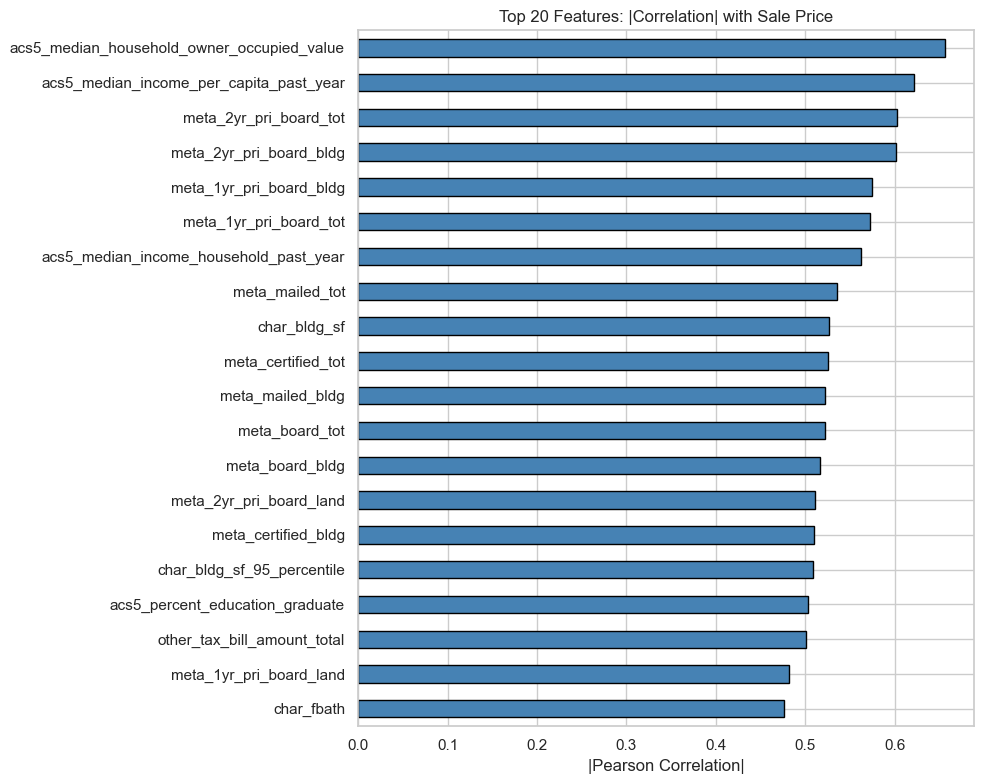

In [17]:
if target_col:
    # Numeric columns only
    numeric_cols = training.select_dtypes(include=[np.number]).columns.tolist()
    
    if target_col in numeric_cols:
        correlations = training[numeric_cols].corr()[target_col].drop(target_col)
        correlations = correlations.abs().sort_values(ascending=False)
        
        print("=== Top 30 Features by |Correlation| with Sale Price ===\n")
        for col, corr in correlations.head(30).items():
            bar = "\u2588" * int(corr * 50)
            sign = "+" if training[numeric_cols].corr()[target_col][col] > 0 else "-"
            print(f"  {sign} {col:<55} {corr:.4f} {bar}")
        
        # Plot top 20
        top20 = correlations.head(20)
        fig, ax = plt.subplots(figsize=(10, 8))
        top20.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
        ax.set_title("Top 20 Features: |Correlation| with Sale Price")
        ax.set_xlabel("|Pearson Correlation|")
        ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig("../outputs/figures/01_top_correlations.png", dpi=150, bbox_inches="tight")
        plt.show()

## 11. Assessment Data Quick Check

In [18]:
print("=== Assessment Data (All Properties) ===\n")
print(f"Shape: {assessment.shape}")
print(f"Columns match training: {set(training.columns) == set(assessment.columns)}")

# Columns in assessment but not training (and vice versa)
only_assessment = set(assessment.columns) - set(training.columns)
only_training = set(training.columns) - set(assessment.columns)
if only_assessment:
    print(f"\nColumns only in assessment_data: {only_assessment}")
if only_training:
    print(f"\nColumns only in training_data: {only_training}")

# Class distribution in full assessment data
if class_col and class_col in assessment.columns:
    print(f"\n=== Assessment Data: Class Distribution ===")
    assess_classes = assessment[class_col].value_counts().sort_index()
    for cls, count in assess_classes.items():
        desc = class_labels.get(str(cls), "Other")
        pct = 100 * count / len(assessment)
        print(f"  {str(cls):<8} {desc:<25} {count:>10,} ({pct:.1f}%)")

=== Assessment Data (All Properties) ===

Shape: (1100173, 191)
Columns match training: False

Columns only in assessment_data: {'hie_num_expired'}

Columns only in training_data: {'sv_outlier_reason1', 'sv_run_id', 'sv_outlier_reason3', 'meta_sale_seller_name', 'meta_sale_price', 'hie_num_active', 'meta_sale_document_num', 'meta_sale_deed_type', 'meta_sale_buyer_name', 'sv_outlier_reason2', 'sv_is_outlier'}

=== Assessment Data: Class Distribution ===
  202      1-Story SF                   113,154 (10.3%)
  203      1-Story SF (lg lot)          345,430 (31.4%)
  204      A-Frame SF                    52,766 (4.8%)
  205      1.5-Story SF                  80,501 (7.3%)
  206      2-Story SF                    41,637 (3.8%)
  207      2+ Story SF                   23,531 (2.1%)
  208      2-Story SF (lg lot)           11,610 (1.1%)
  209      Split Level SF                 6,461 (0.6%)
  210      Townhouse/Row                 17,698 (1.6%)
  211      2-Unit Apt                   152,50

## 12. Summary & Key Findings

Run this section AFTER running all cells above. Fill in your findings:

In [20]:
print("""
=======================================================
  DATA INGESTION & EDA SUMMARY
=======================================================
Training Data:
  - Rows:    {train_rows:,}
  - Columns: {train_cols}
  - Target:  {target}
Assessment Data:
  - Rows:    {assess_rows:,}
  - Columns: {assess_cols}
""".format(
    train_rows=len(training),
    train_cols=training.shape[1],
    target=target_col or "TBD",
    assess_rows=len(assessment),
    assess_cols=assessment.shape[1],
))


  DATA INGESTION & EDA SUMMARY
Training Data:
  - Rows:    413,289
  - Columns: 201
  - Target:  meta_sale_price
Assessment Data:
  - Rows:    1,100,173
  - Columns: 191

